In [1]:
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR')

In [2]:
# Load Models
accident_model = load_model("best_model.keras", compile=False)
severity_model = load_model("severity_model.keras", compile=False)

severity_labels = ["Low", "Medium", "High"]

In [3]:
# Image Preprocessing
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print("Error: Unable to read image")
        return None
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.reshape(img, (1, 224, 224, 3))
    return img

In [4]:
# Prediction Function
def predict_image(img_path):
    img = preprocess_image(img_path)
    if img is None:
        return

    img_show = cv2.imread(img_path)
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
    plt.title("Selected Image", fontsize=14, fontweight='bold')
    plt.axis("off")
    plt.show()

    acc_pred = accident_model.predict(img, verbose=0)
    acc_prob = acc_pred[0][0]
    acc_class = int(acc_prob > 0.5)

    print("\n" + "="*60)
    print("SMART ACCIDENT DETECTION SYSTEM".center(60))
    print("="*60)

    if acc_class == 1:
        detection = "Accident"
        detection_conf = f"{acc_prob*100:.2f}%"

        sev_pred = severity_model.predict(img, verbose=0)
        sev_class = np.argmax(sev_pred)
        sev_conf = np.max(sev_pred)

        severity = severity_labels[sev_class]
        severity_conf = f"{sev_conf*100:.2f}%"
    else:
        detection = "Non-Accident"
        detection_conf = f"{(1-acc_prob)*100:.2f}%"
        severity = "-"
        severity_conf = "-"

    print("\n" + "-"*60)
    print(f"| {'Detection Result':<25} | {detection:<25} |")
    print(f"| {'Detection Confidence':<25} | {detection_conf:<25} |")
    print(f"| {'Severity Level':<25} | {severity:<25} |")
    print(f"| {'Severity Confidence':<25} | {severity_conf:<25} |")
    print("-"*60)

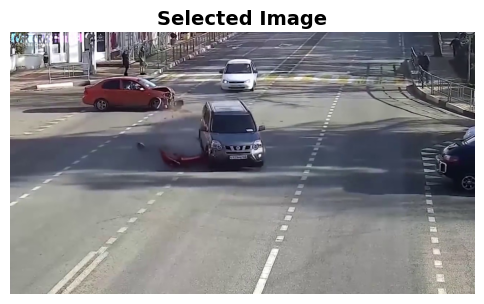


              SMART ACCIDENT DETECTION SYSTEM               

------------------------------------------------------------
| Detection Result          | Accident                  |
| Detection Confidence      | 66.67%                    |
| Severity Level            | High                      |
| Severity Confidence       | 91.79%                    |
------------------------------------------------------------


In [21]:
# Run on Random Image
test_folder = "data/test"

classes = [c for c in os.listdir(test_folder) if not c.startswith(".")]
random_class = random.choice(classes)
class_path = os.path.join(test_folder, random_class)

images = [img for img in os.listdir(class_path)
          if img.endswith((".jpg", ".png", ".jpeg"))]

random_image = random.choice(images)
img_path = os.path.join(class_path, random_image)

predict_image(img_path)